In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering
from sklearn.cluster import KMeans

# Optional NLP-style tools
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
# Load dataset
df = pd.read_csv("petrol_consumption.csv")

# Preview
df.head()

,Petrol_tax,Average_income,Paved_Highways,Population_Driver_licence(%),Petrol_Consumption
0,9.0,3571,1976,0.525,541
1,9.0,4092,1250,0.572,524
2,9.0,3865,1586,0.580,561
3,7.5,4870,2351,0.529,414
4,8.0,4399,431,0.544,410


In [3]:
df.info()
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Petrol_tax                    48 non-null     float64
 1   Average_income                48 non-null     int64  
 2   Paved_Highways                48 non-null     int64  
 3   Population_Driver_licence(%)  48 non-null     float64
 4   Petrol_Consumption            48 non-null     int64  
dtypes: float64(2), int64(3)
memory usage: 2.0 KB


Petrol_tax                      0
Average_income                  0
Paved_Highways                  0
Population_Driver_licence(%)    0
Petrol_Consumption              0
dtype: int64

In [4]:
# Select features (exclude target if needed)
X = df.drop("Petrol_Consumption", axis=1)

In [5]:
# Convert numeric rows into string format
df['text_features'] = X.astype(str).apply(lambda row: ' '.join(row), axis=1)

df['text_features'].head()

0    9.0 3571 1976 0.525
1    9.0 4092 1250 0.572
2     9.0 3865 1586 0.58
3    7.5 4870 2351 0.529
4     8.0 4399 431 0.544
Name: text_features, dtype: str

In [6]:
vectorizer = TfidfVectorizer()

X_tfidf = vectorizer.fit_transform(df['text_features'])

print(X_tfidf.shape)

(48, 132)


In [7]:
# Convert numeric rows into string format
df['text_features'] = X.astype(str).apply(lambda row: ' '.join(row), axis=1)

df['text_features'].head()

0    9.0 3571 1976 0.525
1    9.0 4092 1250 0.572
2     9.0 3865 1586 0.58
3    7.5 4870 2351 0.529
4     8.0 4399 431 0.544
Name: text_features, dtype: str

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

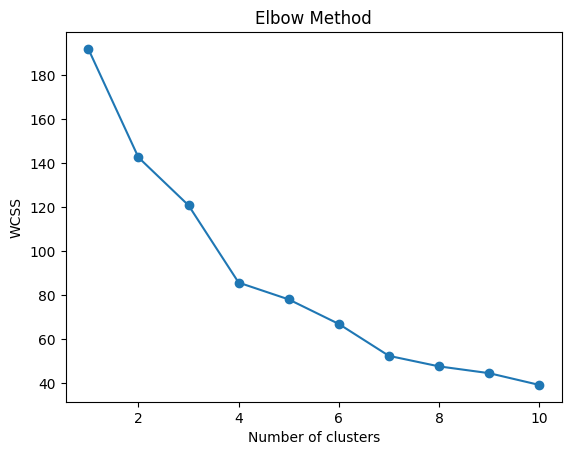

In [9]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [10]:
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

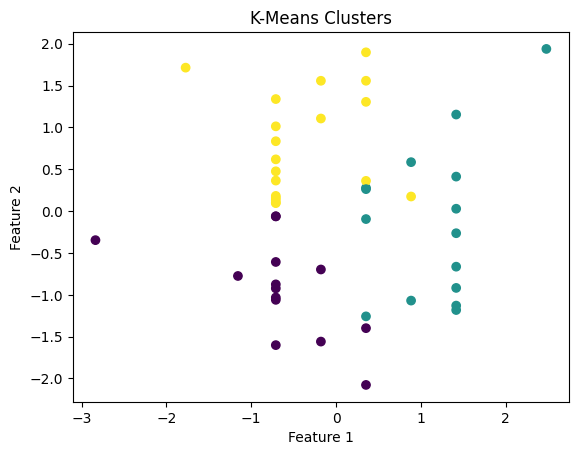

In [11]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, cmap='viridis')
plt.title('K-Means Clusters')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [13]:
df.to_csv("petrol_clusters.csv", index=False)